# 1 mAP comparison for different annotations

In [1]:
import pandas as pd

df = pd.read_csv("results/mAP_results.csv")

df.head()

,dataset,model,gt,AP,AP50,AP75,AP_small,AP_medium,AP_large,AR_1,AR_10,AR_100,AR_small,AR_medium,AR_large
0,coco,gdino,coco_orig_gt,0.568959,0.742470,0.625657,0.400936,0.611131,0.725986,0.414434,0.705343,0.774355,0.622136,0.814872,0.918237
1,coco,gdino,coco_ours_0.5,0.512203,0.712980,0.549478,0.263338,0.503268,0.740434,0.376620,0.613020,0.695800,0.477564,0.713695,0.886441
2,coco,gdino,coco_ours_0.8,0.520982,0.717666,0.561051,0.279969,0.502712,0.729096,0.396975,0.637323,0.717379,0.509286,0.721674,0.887195
3,coco,yolov8l,coco_orig_gt,0.516802,0.685753,0.564292,0.342725,0.571155,0.687392,0.382336,0.624265,0.669873,0.492870,0.729698,0.819444
4,coco,yolov8l,coco_ours_0.5,0.464136,0.646030,0.494668,0.213247,0.458638,0.673005,0.348582,0.551012,0.610383,0.380238,0.639905,0.795677


In [2]:
# model_map = {
#     "gdino": "Grounding DINO~\cite{liu2023grounding}",
#     "yolov8l-worldv2": "YOLOv8-World v2~\cite{cheng2024yoloworld}",
#     "owlvit": "OWL-ViT~\cite{minderer2022owlvit}",
#     "rtdetr-l": "RT-DETR-L~\cite{lv2023detrs}",
#     "yolov8l": "YOLOv8-L~\cite{yolov8_ultralytics}",
#     "frcnn": "Faster R-CNN (ResNet 50)~\cite{ren2016fasterrcnn}"
#     }

# Without citations

model_map = {
    "gdino": "Grounding DINO",
    "yolov8l-worldv2": "YOLOv8-World v2",
    "owlvit": "OWL-ViT",
    "rtdetr-l": "RT-DETR-L",
    "yolov8l": "YOLOv8-L",
    "frcnn": "Faster R-CNN (ResNet 50)"
    }

In [3]:
def generate_latex_table(df, model_map, dataset_map, dataset_name): # table for one dataset
    latex_str  = r"\begin{table}[t]" + "\n"
    latex_str += r"\setlength{\tabcolsep}{3pt}" + "\n" # reduce column separation
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{Performance of object detectors on original vs.\ refined annotations on " + dataset_name + ".}" + "\n"
    latex_str += r" \label{tab:mAP_comparison}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{ccccccccc|cccccccc|cccccccc}" + "\n"
    latex_str += r"\toprule" + "\n" 
    latex_str += r"{Model} & " + "\n"
    latex_str += r"\multicolumn{8}{c}{" + list(dataset_map.values())[0] + r"} & " + "\n"
    latex_str += r"\multicolumn{8}{c}{" + list(dataset_map.values())[1] + r"} & " + "\n"
    latex_str += r"\multicolumn{8}{c}{" + list(dataset_map.values())[2] + r"} \\ " + "\n"
    latex_str += r"\cmidrule(lr){2-9} \cmidrule(lr){10-17} \cmidrule(lr){18-25}" + "\n"
    latex_str += r"& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}" + "\n"
    latex_str += r"& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}" + "\n"
    latex_str += r"& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100} \\ " + "\n"
    latex_str += r"\midrule" + "\n"

    for model in model_map.keys():
        row = model_map[model]
        for dataset in list(dataset_map.keys()):
            try:
                values = df[(df["model"] == model) & (df["gt"] == dataset)][["AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large", "AR_10", "AR_100"]].values[0]
                # AP, AP50, AP75, APS, APM, APL, AR10 = df[(df["model"] == model) & (df["gt"] == dataset)][["AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large", "AR_10"]].values[0]
            except IndexError:
                # AP, AP50, AP75, APS, APM, APL, AR10 = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
                values = [0.0] * 8

            for value in values:
                row+= r" & \percent{" + f"{value:.4f}" + "}"
            
        latex_str += row + " \\\\\n"
    
    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{table}" + "\n"
    return latex_str

## 1.1 COCO

In [4]:
dataset_map = {
    "coco_orig_gt": "Original Annotations",
    "coco_ours_0.5": "Refined Annotations ($p>0.5$)",
    "coco_ours_0.8": "Refined Annotations ($p>0.8$)"
}
s = generate_latex_table(df, model_map, dataset_map, "COCO")
print(s)

\begin{table}[t]
\setlength{\tabcolsep}{3pt}
\centering
\caption{Performance of object detectors on original vs.\ refined annotations on COCO.}
 \label{tab:mAP_comparison}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccc|cccccccc|cccccccc}
\toprule
{Model} & 
\multicolumn{8}{c}{Original Annotations} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.5$)} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.8$)} \\ 
\cmidrule(lr){2-9} \cmidrule(lr){10-17} \cmidrule(lr){18-25}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubs

## 1.2 PascalVOC

In [5]:
dataset_map = {
    "pascal_orig_gt": "Original Annotations",
    "pascal_ours_0.5": "Refined Annotations ($p>0.5$)",
    "pascal_ours_0.8": "Refined Annotations ($p>0.8$)"
}
s = generate_latex_table(df, model_map, dataset_map, "Pascal VOC")
print(s)

\begin{table}[t]
\setlength{\tabcolsep}{3pt}
\centering
\caption{Performance of object detectors on original vs.\ refined annotations on Pascal VOC.}
 \label{tab:mAP_comparison}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccc|cccccccc|cccccccc}
\toprule
{Model} & 
\multicolumn{8}{c}{Original Annotations} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.5$)} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.8$)} \\ 
\cmidrule(lr){2-9} \cmidrule(lr){10-17} \cmidrule(lr){18-25}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\te

## 1.3 KITTI

In [6]:
dataset_map = {
    "kitti_orig_gt": "Original Annotations",
    "kitti_ours_0.5": "Refined Annotations ($p>0.5$)",
    "kitti_ours_0.8": "Refined Annotations ($p>0.8$)"
}
s = generate_latex_table(df, model_map, dataset_map, "KITTI")
print(s)

\begin{table}[t]
\setlength{\tabcolsep}{3pt}
\centering
\caption{Performance of object detectors on original vs.\ refined annotations on KITTI.}
 \label{tab:mAP_comparison}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccc|cccccccc|cccccccc}
\toprule
{Model} & 
\multicolumn{8}{c}{Original Annotations} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.5$)} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.8$)} \\ 
\cmidrule(lr){2-9} \cmidrule(lr){10-17} \cmidrule(lr){18-25}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsub

## 1.4 Cityscapes

In [7]:
dataset_map = {
    "cityscapes_orig_gt": "Original Annotations",
    "cityscapes_ours_0.5": "Refined Annotations ($p>0.5$)",
    "cityscapes_ours_0.8": "Refined Annotations ($p>0.8$)"
}
s = generate_latex_table(df, model_map, dataset_map, "Cityscapes")
print(s)

\begin{table}[t]
\setlength{\tabcolsep}{3pt}
\centering
\caption{Performance of object detectors on original vs.\ refined annotations on Cityscapes.}
 \label{tab:mAP_comparison}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccc|cccccccc|cccccccc}
\toprule
{Model} & 
\multicolumn{8}{c}{Original Annotations} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.5$)} & 
\multicolumn{8}{c}{Refined Annotations ($p>0.8$)} \\ 
\cmidrule(lr){2-9} \cmidrule(lr){10-17} \cmidrule(lr){18-25}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\textsubscript{10} & AR\textsubscript{100}
& AP\textsubscript{50..95} & AP\textsubscript{50} & AP\textsubscript{75} & AP\textsubscript{S} & AP\textsubscript{M} & AP\textsubscript{L} & AR\te

# 1.5 Condensed table for main paper

In [8]:
def format_val(orig, val):
    diff = val - orig
    s = f"\\percent{{{val:.4f}}}"
    if diff > 0.1:
        return f"\\underline{{{s}}}"
    elif diff < -0.1:
        return f"\\textbf{{{s}}}"
    return s

def generate_latex_table(df, model_map, dataset_map):
    latex_str = r"\begin{figure}[t]" + "\n"
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{Performance of object detectors trained on original GT and evaluated on original vs.\ validated GT. Italic denotes improvements $>10$ points, bold denotes decreases $>10$ points.}" + "\n"
    latex_str += r"\label{tab:detection_org_validated}" + "\n"
    latex_str += r"% -------- AP table --------" + "\n"
    latex_str += r"\begin{subfigure}[t]{0.49\linewidth}" + "\n"
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{AP$_{50..95}$ ($\uparrow$)}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{lcc|cc|cc|cc}" + "\n"
    latex_str += r"\toprule" + "\n"
    latex_str += r"& \multicolumn{2}{c}{COCO}" + "\n"
    latex_str += r"& \multicolumn{2}{c}{Pascal VOC}" + "\n"
    latex_str += r"& \multicolumn{2}{c}{KITTI}" + "\n"
    latex_str += r"& \multicolumn{2}{c}{Cityscapes} \\" + "\n"
    latex_str += r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}" + "\n"
    latex_str += r"{Model} & Orig. & Val. & Orig. & Val. & Orig. & Val. & Orig. & Val. \\" + "\n"
    latex_str += r"\midrule" + "\n"

    for model in model_map.keys():
        row = model_map[model]
        for dataset in list(dataset_map.keys()):
            try:
                value_orig = df[(df["model"] == model) & (df["gt"] == dataset + "_orig_gt")]["AP"].values[0]
                value_val = df[(df["model"] == model) & (df["gt"] == dataset + "_ours_0.8")]["AP"].values[0]
            except IndexError:
                value_orig, value_val = 0.0, 0.0
            
            row += f" & \percent{{{value_orig:.4f}}} & " + format_val(value_orig, value_val)
        
        latex_str += row + " \\\\\n"

    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{subfigure}%" + "\n"
    latex_str += r"\hfill" + "\n"
    latex_str += r"% -------- AR table --------" + "\n"
    latex_str += r"\begin{subfigure}[t]{0.49\linewidth}" + "\n"
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{AR$_{10}$ ($\uparrow$)}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{lcc|cc|cc|cc}" + "\n"
    latex_str += r"\toprule" + "\n"
    latex_str += r"& \multicolumn{2}{c}{COCO} " + "\n"
    latex_str += r"& \multicolumn{2}{c}{Pascal VOC}" + "\n"
    latex_str += r"& \multicolumn{2}{c}{KITTI}" + "\n"
    latex_str += r"& \multicolumn{2}{c}{Cityscapes} \\" + "\n"
    latex_str += r"\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}" + "\n"
    latex_str += r"{Model} & Orig. & Val. & Orig. & Val. & Orig. & Val. & Orig. & Val. \\" + "\n"
    latex_str += r"\midrule" + "\n"

    for model in model_map.keys():
        row = model_map[model]
        for dataset in list(dataset_map.keys()):
            try:
                value_orig = df[(df["model"] == model) & (df["gt"] == dataset + "_orig_gt")]["AR_10"].values[0]
                value_val = df[(df["model"] == model) & (df["gt"] == dataset + "_ours_0.8")]["AR_10"].values[0]
            except IndexError:
                value_orig, value_val = 0.0, 0.0
            
            row += f" & \percent{{{value_orig:.4f}}} & " + format_val(value_orig, value_val)
        
        latex_str += row + " \\\\\n"

    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{subfigure}" + "\n"
    latex_str += r"\end{figure}" + "\n"

    return latex_str

In [9]:
dataset_map = {"coco": "coco", "pascal": "pascal", "kitti":"kitti", "cityscapes": "cityscapes"}
s = generate_latex_table(df, model_map, dataset_map)
print(s)

\begin{figure}[t]
\centering
\caption{Performance of object detectors trained on original GT and evaluated on original vs.\ validated GT. Italic denotes improvements $>10$ points, bold denotes decreases $>10$ points.}
\label{tab:detection_org_validated}
% -------- AP table --------
\begin{subfigure}[t]{0.49\linewidth}
\centering
\caption{AP$_{50..95}$ ($\uparrow$)}
\resizebox{\linewidth}{!}{
\begin{tabular}{lcc|cc|cc|cc}
\toprule
& \multicolumn{2}{c}{COCO}
& \multicolumn{2}{c}{Pascal VOC}
& \multicolumn{2}{c}{KITTI}
& \multicolumn{2}{c}{Cityscapes} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
{Model} & Orig. & Val. & Orig. & Val. & Orig. & Val. & Orig. & Val. \\
\midrule
Grounding DINO & \percent{0.5690} & \percent{0.5210} & \percent{0.8005} & \percent{0.7378} & \percent{0.2918} & \underline{\percent{0.3942}} & \percent{0.3419} & \percent{0.4382} \\
YOLOv8-World v2 & \percent{0.4453} & \percent{0.4377} & \percent{0.6965} & \percent{0.6544} & \percent{0

# 2 Soft label-based Metrics

In [10]:
def generate_latex_table(df, model_map, dataset_name, similarity_measure = "tv_similarity", score_to_sort = "entropy_based_score"): # table for one dataset
    latex_str  = r"\begin{table}[t]" + "\n"
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{Soft label-based evaluation of object detector performance on " + dataset_name + ".}" + "\n"
    latex_str += r"\label{tab:soft_label_based_benchmark}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{ccccccccccc}" + "\n"
    latex_str += r"\toprule" + "\n" 
    latex_str += r"{Model} " + "\n"
    latex_str += r"& AUSRC\textsubscript{50..95}\,$\uparrow$ & AUSRC\textsubscript{50} & AUSRC\textsubscript{75} & AUSRC\textsubscript{S} & AUSRC\textsubscript{M} & AUSRC\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & \sqrt{\mathrm{JS}}\textsubscript{TP} \\" + "\n"
    latex_str += r"\midrule" + "\n"

    for model in model_map.keys():
        row = model_map[model]
        try:
            df_filtered = df[
                (df["model"] == model) &
                (df["similarity_measure"] == similarity_measure)
                & (df["score_name"] == score_to_sort)
            ]

            AUSRC = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["AUSRC"].values.mean()
            
            AUSRC_50 = df_filtered[
                (df_filtered["object_size"] == "all") &
                (df_filtered["iou"] == 0.5)
                ]["AUSRC"].values[0]
            
            AUSRC_75 = df_filtered[
                (df_filtered["object_size"] == "all") &
                (df_filtered["iou"] == 0.75)
                ]["AUSRC"].values[0]
            
            AUSRC_S = df_filtered[
                (df_filtered["object_size"] == "small")
                ]["AUSRC"].values.mean()
            
            AUSRC_M = df_filtered[
                (df_filtered["object_size"] == "medium")
                ]["AUSRC"].values.mean()
            
            AUSRC_L = df_filtered[
                (df_filtered["object_size"] == "large")
                ]["AUSRC"].values.mean()
            
            TV = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_TVD_all"].values.mean()
            
            TV_TP = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_TVD_matched"].values.mean()

            JS = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_JSD_all"].values.mean()

            JS_TP = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_JSD_matched"].values.mean()

            values = [AUSRC, AUSRC_50, AUSRC_75, AUSRC_S, AUSRC_M, AUSRC_L, TV, TV_TP, JS, JS_TP]

        except IndexError:
            values = [0.0] * 10

        for value in values:
            row+= r" & \percent{" + f"{value:.4f}" + "}"
            
        latex_str += row + " \\\\\n"
    
    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{table}" + "\n"
    return latex_str

In [11]:
model_map = {
    "gdino": "Grounding DINO~\cite{liu2023grounding}",
    "yolov8l-worldv2": "YOLOv8-World v2~\cite{cheng2024yoloworld}",
    "owlvit": "OWL-ViT~\cite{minderer2022owlvit}",
    "rtdetr-l": "RT-DETR-L~\cite{lv2023detrs}",
    "yolov8l": "YOLOv8-L~\cite{yolov8_ultralytics}",
    "frcnn": "Faster R-CNN (ResNet 50)~\cite{ren2016fasterrcnn}"
    }

for k in list(model_map.keys()):
    model_map[k] = model_map[k].split("~")[0] # Remove the citation part for better display in the table

## 2.1 COCO

In [12]:
dataset = "coco_ours" # name given: {dataset}_ours

for i, model in enumerate(list(model_map.keys())):
    if i == 0:
        df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        df["model"] = [model] * len(df)
    else:
        temp_df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        temp_df["model"] = [model] * len(temp_df)
        df = pd.concat([df, temp_df], ignore_index=True)

s = generate_latex_table(df, model_map, "COCO", similarity_measure = "tv", score_to_sort="entropy")
print(s)

\begin{table}[t]
\centering
\caption{Soft label-based evaluation of object detector performance on COCO.}
\label{tab:soft_label_based_benchmark}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccccc}
\toprule
{Model} 
& AUSRC\textsubscript{50..95}\,$\uparrow$ & AUSRC\textsubscript{50} & AUSRC\textsubscript{75} & AUSRC\textsubscript{S} & AUSRC\textsubscript{M} & AUSRC\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & \sqrt{\mathrm{JS}}\textsubscript{TP} \\
\midrule
Grounding DINO & \percent{0.5508} & \percent{0.7905} & \percent{0.5801} & \percent{0.3842} & \percent{0.6033} & \percent{0.7875} & \percent{0.1198} & \percent{0.3823} & \percent{0.1636} & \percent{0.3495} \\
YOLOv8-World v2 & \percent{0.4808} & \percent{0.7006} & \percent{0.5015} & \percent{0.3060} & \percent{0.5602} & \percent{0.7032} & \percent{0.1641} & \percent{0.3758} & \percent{0.2230} & \percent{0.3570} \\
OWL-ViT & \percent{0.3583} & \percent{0.5865} & \percent{0.3543} 

## 2.2 Pascal VOC

In [13]:
dataset = "pascal_ours" # name given: {dataset}_ours

for i, model in enumerate(list(model_map.keys())):
    if i == 0:
        df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        df["model"] = [model] * len(df)
    else:
        temp_df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        temp_df["model"] = [model] * len(temp_df)
        df = pd.concat([df, temp_df], ignore_index=True)

s = generate_latex_table(df, model_map, "Pascal VOC", similarity_measure = "tv", score_to_sort="entropy")
print(s)

\begin{table}[t]
\centering
\caption{Soft label-based evaluation of object detector performance on Pascal VOC.}
\label{tab:soft_label_based_benchmark}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccccc}
\toprule
{Model} 
& AUSRC\textsubscript{50..95}\,$\uparrow$ & AUSRC\textsubscript{50} & AUSRC\textsubscript{75} & AUSRC\textsubscript{S} & AUSRC\textsubscript{M} & AUSRC\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & \sqrt{\mathrm{JS}}\textsubscript{TP} \\
\midrule
Grounding DINO & \percent{0.8173} & \percent{0.9744} & \percent{0.8768} & \percent{0.5822} & \percent{0.7603} & \percent{0.9022} & \percent{0.0169} & \percent{0.2417} & \percent{0.0217} & \percent{0.2484} \\
YOLOv8-World v2 & \percent{0.7520} & \percent{0.9360} & \percent{0.8126} & \percent{0.5131} & \percent{0.6950} & \percent{0.8247} & \percent{0.0442} & \percent{0.3481} & \percent{0.0695} & \percent{0.3429} \\
OWL-ViT & \percent{0.6929} & \percent{0.9224} & \percent{0.

## 2.3 KITTI

In [14]:
dataset = "kitti_ours" # name given: {dataset}_ours

for i, model in enumerate(list(model_map.keys())):
    if i == 0:
        df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        df["model"] = [model] * len(df)
    else:
        temp_df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        temp_df["model"] = [model] * len(temp_df)
        df = pd.concat([df, temp_df], ignore_index=True)

df["mean_JSD_matched"] = df["mean_JSD_matched"].fillna(1.0) # Fill NaN values with 1.0 
df["mean_TVD_matched"] = df["mean_TVD_matched"].fillna(1.0) # Fill NaN values with 1.0 

s = generate_latex_table(df, model_map, "KITTI", similarity_measure = "tv", score_to_sort="entropy")
print(s)

\begin{table}[t]
\centering
\caption{Soft label-based evaluation of object detector performance on KITTI.}
\label{tab:soft_label_based_benchmark}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccccc}
\toprule
{Model} 
& AUSRC\textsubscript{50..95}\,$\uparrow$ & AUSRC\textsubscript{50} & AUSRC\textsubscript{75} & AUSRC\textsubscript{S} & AUSRC\textsubscript{M} & AUSRC\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & \sqrt{\mathrm{JS}}\textsubscript{TP} \\
\midrule
Grounding DINO & \percent{0.6054} & \percent{0.8769} & \percent{0.6335} & \percent{0.4450} & \percent{0.7328} & \percent{0.8821} & \percent{0.0423} & \percent{0.4025} & \percent{0.0681} & \percent{0.3836} \\
YOLOv8-World v2 & \percent{0.4970} & \percent{0.7072} & \percent{0.5178} & \percent{0.2844} & \percent{0.6874} & \percent{0.7911} & \percent{0.0739} & \percent{0.4961} & \percent{0.1089} & \percent{0.4504} \\
OWL-ViT & \percent{0.2911} & \percent{0.5617} & \percent{0.2624}

## 2.4 Cityscapes

In [15]:
dataset = "cityscapes_ours" # name given: {dataset}_ours

for i, model in enumerate(list(model_map.keys())):
    if i == 0:
        df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        df["model"] = [model] * len(df)
    else:
        temp_df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        temp_df["model"] = [model] * len(temp_df)
        df = pd.concat([df, temp_df], ignore_index=True)

s = generate_latex_table(df, model_map, "Cityscapes", similarity_measure = "tv", score_to_sort="entropy")
print(s)

\begin{table}[t]
\centering
\caption{Soft label-based evaluation of object detector performance on Cityscapes.}
\label{tab:soft_label_based_benchmark}
\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccccccc}
\toprule
{Model} 
& AUSRC\textsubscript{50..95}\,$\uparrow$ & AUSRC\textsubscript{50} & AUSRC\textsubscript{75} & AUSRC\textsubscript{S} & AUSRC\textsubscript{M} & AUSRC\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & \sqrt{\mathrm{JS}}\textsubscript{TP} \\
\midrule
Grounding DINO & \percent{0.5486} & \percent{0.7939} & \percent{0.5713} & \percent{0.3162} & \percent{0.5440} & \percent{0.7273} & \percent{0.1237} & \percent{0.3581} & \percent{0.1529} & \percent{0.3623} \\
YOLOv8-World v2 & \percent{0.4106} & \percent{0.6252} & \percent{0.4221} & \percent{0.0852} & \percent{0.3998} & \percent{0.7100} & \percent{0.1190} & \percent{0.3823} & \percent{0.1660} & \percent{0.3717} \\
OWL-ViT & \percent{0.2419} & \percent{0.4883} & \percent{0.

# 2.5 Condensed COCO table for main paper

In [16]:
def generate_latex_table(df, model_map, dataset_name, similarity_measure = "tv_similarity", score_to_sort = "entropy_based_score"): # table for one dataset
    latex_str  = r"\begin{table}[t]" + "\n"
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{Soft label-based evaluation of object detector performance on " + dataset_name + ".}" + "\n"
    latex_str += r"\label{tab:soft_label_based_benchmark}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{cccccccc}" + "\n"
    latex_str += r"\toprule" + "\n" 
    latex_str += r"{Model} " + "\n"
    # latex_str += r"& AS\textsubscript{50..95}\,$\uparrow$ & AS\textsubscript{S}\,$\uparrow$ & AS\textsubscript{L}\,$\uparrow$ & TVD\,$\downarrow$ & TVD\textsubscript{TP}\,$\downarrow$ & $\sqrt{\mathrm{JS}}\,\downarrow$ & $\sqrt{\mathrm{JS}}$\textsubscript{TP}\,$\downarrow$ \\" + "\n"
    latex_str += r"& AS\textsubscript{50..95}\,$\uparrow$ & AS\textsubscript{S} & AS\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & $\sqrt{\mathrm{JS}}$\textsubscript{TP} \\" + "\n"
    latex_str += r"\midrule" + "\n"

    for model in model_map.keys():
        row = model_map[model]
        try:
            df_filtered = df[
                (df["model"] == model) &
                (df["similarity_measure"] == similarity_measure)
                & (df["score_name"] == score_to_sort)
            ]

            AUSRC = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["AUSRC"].values.mean()
            
            AUSRC_S = df_filtered[
                (df_filtered["object_size"] == "small")
                ]["AUSRC"].values.mean()
            
            AUSRC_L = df_filtered[
                (df_filtered["object_size"] == "large")
                ]["AUSRC"].values.mean()
            
            TV = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_TVD_all"].values.mean()
            
            TV_TP = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_TVD_matched"].values.mean()

            JS = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_JSD_all"].values.mean()

            JS_TP = df_filtered[
                (df_filtered["object_size"] == "all")
                ]["mean_JSD_matched"].values.mean()

            values = [AUSRC, AUSRC_S, AUSRC_L, TV, TV_TP, JS, JS_TP]

        except IndexError:
            values = [0.0] * 7

        for value in values:
            row+= r" & \percent{" + f"{value:.4f}" + "}"
            
        latex_str += row + " \\\\\n"
    
    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{table}" + "\n"
    return latex_str

In [17]:
dataset = "coco_ours" # name given: {dataset}_ours

for i, model in enumerate(list(model_map.keys())):
    if i == 0:
        df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        df["model"] = [model] * len(df)
    else:
        temp_df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")
        temp_df["model"] = [model] * len(temp_df)
        df = pd.concat([df, temp_df], ignore_index=True)

s = generate_latex_table(df, model_map, "COCO", similarity_measure = "tv", score_to_sort="entropy")
print(s)

\begin{table}[t]
\centering
\caption{Soft label-based evaluation of object detector performance on COCO.}
\label{tab:soft_label_based_benchmark}
\resizebox{\linewidth}{!}{
\begin{tabular}{cccccccc}
\toprule
{Model} 
& AS\textsubscript{50..95}\,$\uparrow$ & AS\textsubscript{S} & AS\textsubscript{L} & TVD\,$\downarrow$ & TVD\textsubscript{TP} & $\sqrt{\mathrm{JS}}\,\downarrow$ & $\sqrt{\mathrm{JS}}$\textsubscript{TP} \\
\midrule
Grounding DINO & \percent{0.5508} & \percent{0.3842} & \percent{0.7875} & \percent{0.1198} & \percent{0.3823} & \percent{0.1636} & \percent{0.3495} \\
YOLOv8-World v2 & \percent{0.4808} & \percent{0.3060} & \percent{0.7032} & \percent{0.1641} & \percent{0.3758} & \percent{0.2230} & \percent{0.3570} \\
OWL-ViT & \percent{0.3583} & \percent{0.1402} & \percent{0.6781} & \percent{0.1386} & \percent{0.7524} & \percent{0.1845} & \percent{0.6305} \\
RT-DETR-L & \percent{0.4910} & \percent{0.3226} & \percent{0.7454} & \percent{0.1406} & \percent{0.4688} & \percent{0.1934

# 3 Correlation of Metrics

Compare AUSRC with AP on our refined annotations.

In [18]:
def get_AUSRC(model, dataset, similarity_measure = "tv", score_to_sort = "entropy"):
    df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")

    df_filtered = df[
                (df["similarity_measure"] == similarity_measure)
                & (df["score_name"] == score_to_sort)
            ]

    AUSRC = df_filtered[
        (df_filtered["object_size"] == "all")
        ]["AUSRC"].values.mean()
    
    return AUSRC

def get_AP(model, dataset):
    df = pd.read_csv("results/mAP_results.csv")
    AP = df[(df["model"] == model) & (df["gt"] == dataset)]["AP"].values[0]
    return AP

def get_TVD(model, dataset, similarity_measure = "tv", score_to_sort = "entropy"):
    df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")

    df_filtered = df[
                (df["similarity_measure"] == similarity_measure)
                & (df["score_name"] == score_to_sort)
            ]
 
    TVD = df_filtered[
        (df_filtered["object_size"] == "all")
        ]["mean_TVD_all"].values.mean()
    
    return TVD

def get_JSD(model, dataset, similarity_measure = "tv", score_to_sort = "entropy"):
    df = pd.read_csv(f"results/{dataset}_{model}_AUSRC_results.csv")

    df_filtered = df[
                (df["similarity_measure"] == similarity_measure)
                & (df["score_name"] == score_to_sort)
            ]
      
    JSD = df_filtered[
        (df_filtered["object_size"] == "all")
        ]["mean_JSD_all"].values.mean()
    
    return JSD

In [19]:
t = 0.5 # soft label threshold (only 0.5 and 0.8 are available)

results = []

for dataset in ["coco_ours", "pascal_ours", "kitti_ours", "cityscapes_ours"]:
    for model in model_map.keys():
        AUSRC = get_AUSRC(model, dataset)
        AP = get_AP(model, f"{dataset}_{t}")
        TVD = get_TVD(model, dataset)
        JSD = get_JSD(model, dataset)
        results.append((model, dataset, AUSRC, AP, TVD, JSD))

# build dataframe
results_df = pd.DataFrame(results, columns=["model", "dataset", "AUSRC", "AP", "TVD", "JSD"])

In [20]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import sys
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.plot_layout import set_plot_layout
plot_params = set_plot_layout()

In [21]:
model_map = {
    "gdino": "Grounding DINO",
    "yolov8l-worldv2": "YOLOv8-World v2",
    "owlvit": "OWL-ViT",
    "rtdetr-l": "RT-DETR-L",
    "yolov8l": "YOLOv8-L",
    "frcnn": "Faster R-CNN"
    }

dataset_map = {
    "coco_ours": "COCO",
    "pascal_ours": "Pascal VOC",
    "kitti_ours": "KITTI",
    "cityscapes_ours": "Cityscapes"
}

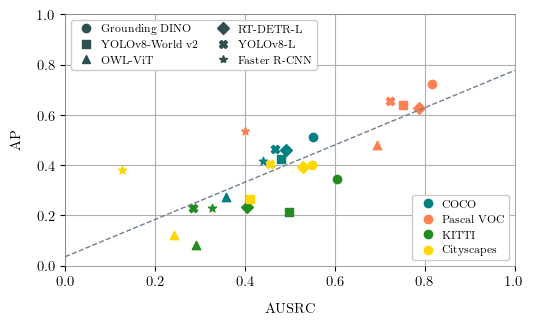

In [22]:
# scatter results with color coding for different datasets and markers for different models

fig = plt.figure()
ax = plt.gca()

colors = plot_params["colors"].copy() # to avoid modifying the original list

colors = [colors[0], colors[1], colors[4], colors[6]] # select 4 distinct colors for the 4 datasets
colors_for_legend = colors.copy() # keep a copy for the legend

markers = ["o", "s", "^", "D", "X", "*"] # one marker per model

for dataset in results_df["dataset"].unique():
    color = colors.pop(0)

    markers_to_pop = markers.copy() # to keep the original list of markers for the legend
    for model in model_map.keys():
        m = markers_to_pop.pop(0)
        model_results = results_df[ (results_df["model"] == model) & (results_df["dataset"] == dataset) ]
        ax.scatter(model_results["AUSRC"], model_results["AP"], label=model_map[model], c=color, marker= m, zorder = 2)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(zorder=1) # to background via zorder

# add linear regression line
x = results_df["AUSRC"].values
y = results_df["AP"].values
coef = np.polyfit(x, y, 1)
line = np.poly1d(coef)
plt.plot([0, 1], line([0, 1]), c="slategray", linestyle="--", label=f"Linear Fit (R²={np.corrcoef(x, y)[0,1]**2:.2f})", zorder=3)


# build custom legend
model_handles = []
for model, marker in zip(model_map.keys(), markers):
    model_handles.append(
        Line2D(
            [0], [0],
            marker=marker,
            color="darkslategray",
            linestyle="None",
            markersize=6,
            label=model_map[model]
        )
    )

dataset_handles = []
for dataset, color in zip(results_df["dataset"].unique(), colors_for_legend):
    dataset_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color=color,
            linestyle="None",
            markersize=6,
            label=dataset_map[dataset]
        )
    )

# First legend (models)
legend1 = ax.legend(
    handles=model_handles,
    ncols = 2,
    #title="Model",
    loc="upper left",
    fontsize=8,
    handletextpad=0.3,
    columnspacing=1.25
)

# Add it manually so it doesn't get overwritten
ax.add_artist(legend1)

# Second legend (datasets)
legend2 = ax.legend(
    handles=dataset_handles,
    # title="Dataset",
    loc="lower right",
    fontsize=8,
    handletextpad=0.3
)

plt.xlabel("AUSRC")
plt.ylabel("AP")

plt.savefig("plots/AUSRC_vs_AP_scatter_plot.pdf", bbox_inches="tight", dpi = 300)

plt.show()

In [23]:
print(f"Linear Fit (R²={np.corrcoef(x, y)[0,1]**2:.2f})")
print(f"Pearson Correlation Coefficient: {np.corrcoef(x, y)[0,1]:.2f}")

Linear Fit (R²=0.61)
Pearson Correlation Coefficient: 0.78


In [24]:
# Correlation with ECE?
calibration_df = pd.read_csv("../calibration/calibration_results.csv")

calibration_df = calibration_df[calibration_df["model"].isin(model_map)] # only keep models for which we have AUSRC results

z = calibration_df["ECE_isotonic_regression"].values

print(f"Correlation AUSRC, ECE: {np.corrcoef(x, z)[0,1]:.2f}")

print(f"Correlation AP, ECE: {np.corrcoef(y, z)[0,1]:.2f}")

# We would expect a negative correlation between AUSRC and ECE, since higher AUSRC should indicate better performance and thus lower calibration error.
# However, while correlation is smaller than for AP, it is moderately positive.
# This is due to models being mixed here, but for individual models we have too few data points to determine correlation.

Correlation AUSRC, ECE: 0.62
Correlation AP, ECE: 0.58


In [25]:
x = results_df["AUSRC"].values
y = results_df["TVD"].values

print(f"Correlation AUSRC, TVD: {np.corrcoef(x, y)[0,1]:.2f}")

x = results_df["AP"].values
y = results_df["TVD"].values

print(f"Correlation AP, TVD: {np.corrcoef(x, y)[0,1]:.2f}")

Correlation AUSRC, TVD: -0.58
Correlation AP, TVD: -0.02


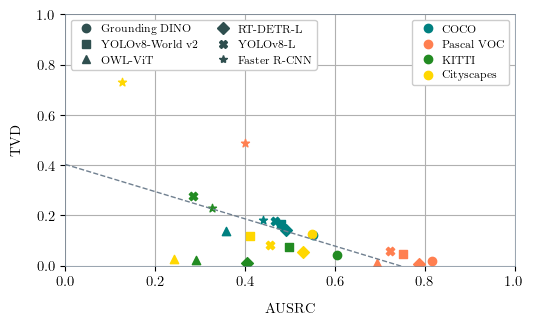

In [26]:
# scatter results with color coding for different datasets and markers for different models

fig = plt.figure()
ax = plt.gca()

colors = plot_params["colors"].copy() # to avoid modifying the original list

colors = [colors[0], colors[1], colors[4], colors[6]] # select 4 distinct colors for the 4 datasets
colors_for_legend = colors.copy() # keep a copy for the legend

markers = ["o", "s", "^", "D", "X", "*"] # one marker per model

for dataset in results_df["dataset"].unique():
    color = colors.pop(0)

    markers_to_pop = markers.copy() # to keep the original list of markers for the legend
    for model in model_map.keys():
        m = markers_to_pop.pop(0)
        model_results = results_df[ (results_df["model"] == model) & (results_df["dataset"] == dataset) ]
        ax.scatter(model_results["AUSRC"], model_results["TVD"], label=model_map[model], c=color, marker= m, zorder = 2)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(zorder=1) # to background via zorder

# add linear regression line
x = results_df["AUSRC"].values
y = results_df["TVD"].values
coef = np.polyfit(x, y, 1)
line = np.poly1d(coef)
plt.plot([0, 1], line([0, 1]), c="slategray", linestyle="--", label=f"Linear Fit (R²={np.corrcoef(x, y)[0,1]**2:.2f})", zorder=3)


# build custom legend
model_handles = []
for model, marker in zip(model_map.keys(), markers):
    model_handles.append(
        Line2D(
            [0], [0],
            marker=marker,
            color="darkslategray",
            linestyle="None",
            markersize=6,
            label=model_map[model]
        )
    )

dataset_handles = []
for dataset, color in zip(results_df["dataset"].unique(), colors_for_legend):
    dataset_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color=color,
            linestyle="None",
            markersize=6,
            label=dataset_map[dataset]
        )
    )

# First legend (models)
legend1 = ax.legend(
    handles=model_handles,
    ncols = 2,
    #title="Model",
    loc="upper left",
    fontsize=8,
    handletextpad=0.3,
    columnspacing=1.25
)

# Add it manually so it doesn't get overwritten
ax.add_artist(legend1)

# Second legend (datasets)
legend2 = ax.legend(
    handles=dataset_handles,
    # title="Dataset",
    loc="upper right",
    fontsize=8,
    handletextpad=0.3
)

plt.xlabel("AUSRC")
plt.ylabel("TVD")

plt.savefig("plots/AUSRC_vs_TVD_scatter_plot.pdf", bbox_inches="tight", dpi = 300)

plt.show()

# 4 Training on soft vs. hard labels

In [27]:
def get_ECE(model, dataset):
    df = pd.read_csv("../calibration/calibration_results.csv")
    ECE = df[(df["model"] == model) & (df["dataset"] == dataset)]["ECE_raw"].values[0]
    return ECE

In [28]:
model_map = {
    "rtdetr-l_hard": "RT-DETR-L",
    "rtdetr-l_soft": r"RT-DETR-L$^\ast$",
    "yolov8l_hard": "YOLOv8-L",
    "yolov8l_soft": r"YOLOv8-L$^\ast$"
    }

results = []
for dataset in ["coco_ours", "pascal_ours", "kitti_ours", "cityscapes_ours"]:
    for model in model_map.keys():
        AUSRC = get_AUSRC(model, dataset)
        AP = get_AP(model, f"{dataset}_{t}")
        TVD = get_TVD(model, dataset)
        JSD = get_JSD(model, dataset)
        ECE = get_ECE(model, dataset.split("_ours")[0]) # Just different naming pattern here, still our datasets used.
        results.append((model, dataset, AUSRC, AP, TVD, JSD, ECE))

# build dataframe
results_df = pd.DataFrame(results, columns=["model", "dataset", "AUSRC", "AP", "TVD", "JSD", "ECE"])

In [29]:
def generate_latex_table(results_df, model_map, bold=True):
    def fmt(val, is_best):
        s = f"\\percent{{{val:.4f}}}"
        if bold and is_best:
            return f"\\textbf{{{s}}}"
        return s

    # define metric directions (important!)
    higher_better = {"AP": True, "AUSRC": True, "ECE": False, "TVD": False, "JSD": False}

    latex_str  = r"\begin{table}[t]" + "\n"
    latex_str += r"\setlength{\tabcolsep}{2pt}" + "\n" # reduce column separation
    latex_str += r"\centering" + "\n"
    latex_str += r"\caption{Performance and calibration of models trained on hard vs.\ soft labels ($\ast$). Values in \%.}" + "\n"
    latex_str += r"\label{tab:training_comparison}" + "\n"
    latex_str += r"\resizebox{\linewidth}{!}{" + "\n"
    latex_str += r"\begin{tabular}{lccccc|ccccc|ccccc|ccccc}" + "\n"
    latex_str += r"\toprule" + "\n" 
    latex_str += r" & " + "\n"
    latex_str += r"\multicolumn{5}{c}{COCO} & " + "\n"
    latex_str += r"\multicolumn{5}{c}{Pascal VOC} & " + "\n"
    latex_str += r"\multicolumn{5}{c}{KITTI} & " + "\n"
    latex_str += r"\multicolumn{5}{c}{Cityscapes} \\ " + "\n"
    latex_str += r"\cmidrule(lr){2-6} \cmidrule(lr){7-11} \cmidrule(lr){12-16} \cmidrule(lr){17-21}" + "\n"
    latex_str += r"{Model} & AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$" + "\n"
    latex_str += r"& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$" + "\n"
    latex_str += r"& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$" + "\n"
    latex_str += r"& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$" + "\n"
    latex_str += r"\\" + "\n"
    latex_str += r"\midrule" + "\n"

    datasets = ["coco_ours", "pascal_ours", "kitti_ours", "cityscapes_ours"]
    metrics = ["AP", "AUSRC", "ECE", "TVD", "JSD"]

    # ---- group models by architecture (remove trailing *)
    def base_model_name(m):
        return m.replace("_hard", "").replace("_soft", "")

    grouped = {}
    for m in model_map.keys():
        base = base_model_name(m)
        grouped.setdefault(base, []).append(m)

    # ---- process each group (e.g. RT-DETR pair)
    for base_model, models in grouped.items():

        # collect values per model
        model_values = {}

        for model in models:
            vals = []
            for dataset in datasets:
                df_filtered = results_df[
                    (results_df["model"] == model) &
                    (results_df["dataset"] == dataset)
                ]

                if len(df_filtered) == 0:
                    vals.extend([0.0]*5)
                else:
                    row = df_filtered.iloc[0]
                    vals.extend([row["AP"], row["AUSRC"], row["ECE"], row["TVD"], row["JSD"]])

            model_values[model] = vals

        # determine best per column
        best_mask = {model: [False]*len(datasets)*5 for model in models}

        for col in range(len(datasets)*5):
            metric = metrics[col % 5]

            values = [(m, model_values[m][col]) for m in models]

            if higher_better[metric]:
                best_val = max(v for _, v in values)
            else:
                best_val = min(v for _, v in values)

            for m, v in values:
                if v == best_val:
                    best_mask[m][col] = True

        # write rows
        for model in models:
            row = model_map[model]
            vals = model_values[model]

            for i, v in enumerate(vals):
                row += " & " + fmt(v, best_mask[model][i])

            latex_str += row + r" \\" + "\n"

        if base_model != list(grouped.keys())[-1]: # if not last group, add  some space
            # latex_str += r"\midrule" + "\n"
            latex_str += r"\addlinespace[0.25em]" + "\n"

    latex_str += r"\bottomrule" + "\n"
    latex_str += r"\end{tabular}" + "\n"
    latex_str += r"}" + "\n"
    latex_str += r"\end{table}" + "\n"

    return latex_str

In [30]:
s = generate_latex_table(results_df, model_map, bold = False)
print(s)

\begin{table}[t]
\setlength{\tabcolsep}{2pt}
\centering
\caption{Performance and calibration of models trained on hard vs.\ soft labels ($\ast$). Values in \%.}
\label{tab:training_comparison}
\resizebox{\linewidth}{!}{
\begin{tabular}{lccccc|ccccc|ccccc|ccccc}
\toprule
 & 
\multicolumn{5}{c}{COCO} & 
\multicolumn{5}{c}{Pascal VOC} & 
\multicolumn{5}{c}{KITTI} & 
\multicolumn{5}{c}{Cityscapes} \\ 
\cmidrule(lr){2-6} \cmidrule(lr){7-11} \cmidrule(lr){12-16} \cmidrule(lr){17-21}
{Model} & AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$
& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$
& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$
& AP\,$\uparrow$ & AS\,$\uparrow$ & ECE\,$\downarrow$ & TVD\,$\downarrow$ & $\sqrt{\mathrm{JS}}$\,$\downarrow$
\\
\midrule
RT-DETR-L & \percent{0.4868} & \percent{0.5270} & \per